# Lesson 07b: DimeNet and the insufficiency of distance-only GNNs

**What you will learn**

- A concrete, runnable example from two genuinely different structures that *no*
  distance-based graph neural network (GNN), including SchNet, at any cutoff,
  can distinguish.
- **Directional message passing**: Embeddings that live on *directed edges*,
  $m_{ji}$, instead of atoms, are updated using the **angles** between edges,
  while the prediction stays invariant.
- DimeNet's physically motivated **Bessel radial basis** and 2D spherical
  Fourier-Bessel basis, alongside the **DimeNet++** efficiency fixes.
- A **simplified, educational DimeNet-style model** (simplifications stated
  explicitly), trained on the same LJ-argon data as Lesson 07a. We will discuss
  the reasons behind the small gain here.
- The cost of feature triplets: $O(Nk^2)$ vs. $O(Nk)$. This is our motivation
  for Part IV's equivariant approach.

**Prerequisites:** 

- [Lesson 07a](07a_schnet.ipynb): SchNet, forces from autograd, the training pipeline (reused here),
- [Lesson 05b](05b_radial_basis_and_cutoffs.ipynb): Radial bases and cutoffs.

In [1]:
import sys
sys.path.insert(0, "..")    # Make course_utils importable

import copy, time, warnings
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from course_utils.data import make_lj_argon_dataset, train_val_split, radius_graph
from course_utils.plotting import (plot_training_curves, scene3d,
                                    draw_point_cloud, show3d)
from course_utils.equivariance import assert_model_equivariant

warnings.filterwarnings("ignore", category=FutureWarning)  # ASE Langevin deprecation notice
torch.manual_seed(0); np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
silu = nn.functional.silu          # "swish" σ(x) = x·sigmoid(x), DimeNet's activation
print(f"device = {device}, torch {torch.__version__}")

device = cuda, torch 2.7.1+cu126


## Distance-based GNNs are incomplete

Lesson 07a's SchNet sees a molecule only through its atom types and pairwise
distances:  a **distance-graph NN (dGNN)**. Message passing makes such models
surprisingly powerful. That is, after two message passing iterations, an atom
"knows" about not only its own interatomic distances but its neighbors'
distances too, which is often enough to reconstruct the angles implicitly.

[Pozdnyakov & Ceriotti](https://arxiv.org/pdf/2201.07136) analyze dGNNs with a
distance-decorated **Weisfeiler–Lehman (WL) test**. Here, they iteratively
re-label each node by the hash

$$
h_i = \mathrm{hash}\big(l_i,\ \{\!\{\,(l_j, r_{ij})\,\}\!\}_{j=1}^{n}\big),
$$

where $l_i$ is the node label, $r_{ij}$ the distance, and $\{\!\{\cdot\}\!\}$ a
*multiset* (an unordered set with repetition). If two structures produce
identical multisets of hashes at every iteration, **no dGNN can ever distinguish
them**, regardless of weights, depth, or training. This manuscript presents a
family of structure pairs, $\mathcal{A}^\pm$, that are *distinct* (different
angle sets, and different physics) yet WL-indistinguishable **for any cutoff,
even fully connected**.

### How the counterexample is built

Start with an infinite chain of identical atoms that repeats with period $p$
along the $x$-axis. Each repeating unit contains six points, arranged in three
pairs that we label $(C, C')$, $(V, V')$ and $(W, W')$. The two members of each
pair are related by the same operation: shift by half a period along $x$ and
mirror in $z$,

$$
q = (x, y, z) \;\longmapsto\; q' = \big(x + \tfrac{p}{2},\ y,\ -z\big).
$$

The $V$ pair lies in the $z = 0$ plane and the $W$ pair sits at height $\pm
w_z$: both are the *same* in the two structures. The only difference between
$\mathcal{A}^+$ and $\mathcal{A}^-$ is the sign of the $z$-coordinate of the $C$
pair; that is $C = (p/4,\, c_y,\, \pm c_z)$.

Why does this flip preserve every distance? Because $C$ sits exactly halfway
between $W$ and its shifted-and-mirrored partner $W'$ along $x$, sending $c_z
\to -c_z$ simply *swaps* the two distances: the distance from $C$ to $W$ in
$\mathcal{A}^+$ equals the distance from $C$ to $W'$ in $\mathcal{A}^-$, and
vice versa (the same happens for $C'$). Every atom therefore sees exactly the
same *multiset* of neighbor distances in both structures. As such, the WL hashes
agree at every iteration. The *angles*, however, change, so that the two
structures become genuinely different shapes with different physics.

An infinite chain is not a molecule, so the last step makes the pair finite: we
take $P$ consecutive periods of the chain (here $P = 2$) and wrap them into a
closed ring around the $z$-axis, turning $x$ into a polar angle $\theta = 2\pi x
/(pP)$ and $y$ into a small radial offset from a ring of radius $pP/2\pi$. The
result is two finite clouds of $6P = 12$ points each that inherit the distance
degeneracy (we verify this numerically below). [Pozdnyakov &
Ceriotti](https://arxiv.org/pdf/2201.07136) show that such pairs can even be
realized as configurations of four water molecules. Let's build the folded pair
and check everything numerically.

In [2]:
def degenerate_pair(p=6.0, c_y=0.2, c_z=0.8, v_x=1.1, v_y=-0.4, w_y=0.6, w_z=1.3, P=2):
    '''Pozdnyakov & Ceriotti (2022): A+/A- pair'''
    
    # Primed = (p/2 + x, y, -z)
    def unit_cell(sign):
        C = (p / 4, c_y, sign * c_z)
        W = (p / 2, w_y, w_z)
        V = (v_x, v_y, 0.0)
        prime = lambda q: (p / 2 + q[0], q[1], -q[2])
        return [C, prime(C), V, prime(V), W, prime(W)]
    
    # Wrap P periods around z
    def fold(points):
        out = []
        for k in range(P):
            for (x, y, z) in points:
                theta = 2 * np.pi * (x + k * p) / (p * P)
                r = P * p / (2 * np.pi) + y
                out.append((r * np.cos(theta), r * np.sin(theta), z))
        return torch.tensor(out, dtype=torch.float64)
    
    # Return the two structures A+ and A- as torch tensors of shape (6*P, 3) 
    return fold(unit_cell(+1)), fold(unit_cell(-1))

# Generate the two structures and print their sizes
A_plus, A_minus = degenerate_pair()
print("two finite structures with", len(A_plus), "points each")

two finite structures with 12 points each


In [3]:
# Sorted list of all pair distances
def distance_multiset(pos):
    d = torch.cdist(pos, pos)
    iu = torch.triu_indices(len(pos), len(pos), offset=1)
    return d[iu[0], iu[1]].sort().values

# Sorted cos(angle) over all triplets i-j-k
def angle_multiset(pos):
    # vecs[j, i] = r_i - r_j
    vecs = pos.unsqueeze(0) - pos.unsqueeze(1)
    n = len(pos); cos = []
    for j in range(n):
        for i in range(n):
            for k in range(i + 1, n):
                if i == j or k == j: continue
                u, v = vecs[j, i], vecs[j, k]
                cos.append((u @ v / (u.norm() * v.norm())).item())
    return torch.tensor(sorted(cos))

# Compare the two structures
dd = (distance_multiset(A_plus) - distance_multiset(A_minus)).abs().max()
da = (angle_multiset(A_plus) - angle_multiset(A_minus)).abs().max()
print(f"pair-distance multisets:  max difference = {dd:.2e}   (identical)")
print(f"angle multisets:          max difference = {da:.2e}   (DIFFERENT -> distinct shapes)")

pair-distance multisets:  max difference = 8.88e-16   (identical)
angle multisets:          max difference = 1.64e-01   (DIFFERENT -> distinct shapes)


In [4]:
# Visualize the two structures
labels = ["C", "C'", "V", "V'", "W", "W'"]
colors = ["C0", "C0", "C1", "C1", "C2", "C2"]
symbols = ["circle", "diamond", "circle", "diamond", "circle", "diamond"]

# The two environments differ only in angles, so rotate them to see it
fig = scene3d(1, 2, titles=["A+  (same distances, different angles)",
                            "A-  (same distances, different angles)"], title_dy=-0.05)
for panel, pos in enumerate([A_plus, A_minus]):
    for t in range(6):                                    # 6 point types, P=2 copies each
        draw_point_cloud(pos[t::6], fig=fig, cell=(1, panel + 1), color=colors[t],
                         symbol=symbols[t], size=7,
                         label=labels[t] if panel == 0 else None)
show3d(fig, axes=True)

<plotly figure: interactive 3D scene>

### A dGNN really cannot tell them apart

The WL test is architecture-independent. As such, we can demonstrate it with a
*random, untrained* distance-based message-passing network: If the two
structures produced different outputs for *any* weights, they would be
WL-distinguishable. 

We use a fully connected graph (cutoff larger than the biggest distance), the
hardest case for the counterexample, and it still holds.

In [5]:
class MiniDGNN(nn.Module):
    '''A generic distance-based MPNN (the SchNet blueprint), random weights, float64.'''
    
    # We use a fully connected graph (cutoff larger than the biggest distance)
    def __init__(self, F=32, n_rbf=16, r_max=10.0):
        super().__init__()
        # Create a grid of radial basis function centers, evenly spaced in [0, r_max]
        self.register_buffer("mu", torch.linspace(0.0, r_max, n_rbf))
        
        # Message function: takes in a node feature vector and a radial basis
        # function vector, outputs a new node feature vector
        self.msg = nn.Sequential(nn.Linear(F + n_rbf, F), nn.Tanh(), nn.Linear(F, F))
        
        # Readout function: takes in a node feature vector and outputs a scalar energy
        self.readout = nn.Linear(F, 1)
        
        # Number of features per node
        self.F = F
    
    # Forward pass: compute the "energy" of a point cloud
    def forward(self, pos):
        # Fully connected graph here
        i, j = radius_graph(pos, r_cut=10.0)
        
        # Compute the radial basis functions
        e = torch.exp(-10.0 * ((pos[j] - pos[i]).norm(dim=-1, keepdim=True) - self.mu) ** 2)
        
        # One species -> identical init
        x = torch.ones(len(pos), self.F, dtype=pos.dtype)
        
        # 3 rounds of message passing
        for _ in range(3):
            m = self.msg(torch.cat([x[j], e], dim=-1))
            x = x + torch.zeros_like(x).index_add_(0, i, m)
        
        # Readout: sum over all nodes
        return self.readout(x).sum()

# Initialize the dGNN and compute energies for both structures
dgnn = MiniDGNN().double()
E_p, E_m = dgnn(A_plus).item(), dgnn(A_minus).item()
print(f"dGNN(A+) = {E_p:.12f}\ndGNN(A-) = {E_m:.12f}\ndifference = {abs(E_p - E_m):.2e}")

dGNN(A+) = -28.836528410246
dGNN(A-) = -28.836528410246
difference = 7.11e-15


Identical energies to machine precision! This observation holds for *every*
weight setting, every depth, every cutoff. The fix suggested by the paper's is
to use the **angular information**: 3-body descriptors, or GNNs such as
DimeNet/GemNet that pass messages *between edges*. That is directional message
passing.

## Directional message passing (DimeNet)

Classical force fields decompose the energy as:

$$
E = E_\text{bonds} + E_\text{angle} + E_\text{torsion} + E_\text{non-bonding},
$$

where $E_\text{bonds}$, $E_\text{angle}$, $E_\text{torsion}$, and
$E_\text{non-bonding}$ are the energy contributions from bonds, angles, torsions
(i.e., rotations around bonds based on dihedral angles), and non-bonded
interactions (i.e., van der Waals and electrostatic interactions), respectively.
Noting that a standard message-passing GNN updates the atom $i$'s features in
layer $l$, $h_i^{(l)}$, using an update function,$f_\text{update}$, of the form,

$$
h_i^{(l+1)} = f_\text{update}\Big(h_i^{(l)}, \sum_{j \in \mathcal{N}_i} f_\text{int}\big(h_j^{(l)}, e^{(l)}_{(ij)}\big)\Big)
$$

it only sees the distance-based edge embeddings, $e^{(l)}_{(ij)}$. As such, the
predicted total energy of the model lacks the angle, torsion and the non-bonding
terms. Both update and interaction functions, $f_\text{update}$ and
$f_\text{int}$, are often implemented as neural networks. 

The DimeNet's main idea is to embed the *directed edges* alongside the atomic
embeddings. The **message embedding**, $m_{ji} \in \mathbb{R}^F$, is associated
with the atom pair $j \to i$. The atomic embedding is recovered as the sum of
its incoming messages, $h_i = \sum_{j \in \mathcal{N}_i} m_{ji}$. Each message
is tied to a *direction* in space, and directions rotate with the molecule.
Thus, relative directional information (angles) between messages is preserved,
while the network only ever consumes **invariant scalars**: distances and
angles.

A message $m_{ji}$ is updated from the messages $m_{kj}$ flowing *into its
source atom* $j$ (excluding the one coming back from $i$), using the angle
$\alpha^{(kj,ji)} = \angle\, \vec x_k\, \vec x_j\, \vec x_i$ between the two
edges at the vertex $j$. Thus, the **directional message-passing equation** can
be written as

$$
m_{ji}^{(l+1)} = f_\text{update}\Big( m_{ji}^{(l)},
\sum_{k \in \mathcal{N}_j \setminus \{i\}}
f_\text{int}\big( m_{kj}^{(l)},\, e_\mathrm{RBF}^{(ji)},\, a_\mathrm{SBF}^{(kj,ji)} \big) \Big),
$$

where $e_\mathrm{RBF}^{(ji)}$ is a radial-basis representation of $d_{ji}$ and
$a_\mathrm{SBF}^{(kj,ji)}$ is a joint 2D basis of $\big(d_{kj},\,
\alpha^{(kj,ji)}\big)$. This aggregation over pairs of edges, **triplets** $(k,
j, i)$ of atoms, is what lets the model learn the $E_\text{angle}$ directly.
Consequently, the model can distinguish among structures (like the
$\mathcal{A}^+/\mathcal{A}^-$ pair above) that lead to the failure of every
dGNN. Message embeddings are pair embeddings, connecting DimeNet to the provably
more expressive higher-order WL hierarchies.

### Bessel radial basis and the 2D spherical Fourier–Bessel basis

Instead of Gaussians (Lesson 07a), DimeNet derives its bases from the free
Schrödinger/Helmholtz equation inside a sphere with a cutoff radius, $c$, and
the boundary condition, $\Psi(c) = 0$. The 1D **radial Bessel basis** for
$d_{ji}$, expressed as

$$
\tilde e_\mathrm{RBF,n}(d) = \sqrt{\frac{2}{c}}\, \frac{\sin\!\big(\tfrac{n_1\pi}{c} d\big)}{d},
\qquad n_1 \in \{1, 2, \ldots, N_\mathrm{RBF}\},
$$

are real-valued andorthogonal with a bounded maximum frequency $n_1\pi/c$ (a
built-in regularizer). The radial Bessel functions match the accuracy of
Gaussian-RBFs with $4$–$20\times$ fewer basis functions. The joint 2D spherical
Fourier-Bessel basis, $\tilde a_\mathrm{SBF,ln}(d, \alpha) \in
\mathbb{R}^{N_\mathrm{SHBF} \times N_\mathrm{SRBF}}$, combines spherical Bessel
functions, $j_l$, with spherical harmonics, $Y_l^0$:

$$ \tilde a_\mathrm{SBF,ln_2}(d, \alpha) = \sqrt{\frac{2}{c^3\,
j_{l+1}^2(z_{ln_2})}}\; j_l\!\Big(\frac{z_{ln_2}}{c} d\Big)\, Y_l^0(\alpha), \qquad
n_2 \in \{1, 2, \ldots, N_\mathrm{SRBF}\}, \qquad \text{and} \qquad l \in \{0, 1,
\ldots, N_\mathrm{SHBF}-1\} $$

where $z_{ln}$ (dropping the subscript) is the $n$-th root of $l$-th-order
Bessel function, $j_l$. Both bases are multiplied by a smooth **envelope**
$u(d)$ with a root of multiplicity 3 at the cutoff. With $p = 6$, $d$ in units
of $c$, one can write

$$
u(d) = 1 - \frac{(p+1)(p+2)}{2} d^{p} + p(p+2)\, d^{p+1} - \frac{p(p+1)}{2} d^{p+2}.
$$

Thus, the model becomes **twice continuously differentiable**, $\mathcal{C}^2$,
which is a desired property for training machine learning models on forces. The
**embedding block** initializes messages from the endpoint atom embeddings and
the distance as:

$$ m_{ji}^{(1)} = \mathrm{SiLU}\big( [\, h_j^{(0)}\, \Vert\, h_i^{(0)}\, \Vert\,
e_\mathrm{RBF}^{(ji)}\,] W + b \big), $$

where $\Vert$ denotes concatenation and $\mathrm{SiLU}$ is a self-gated Swish or
sigmoid linear unit (SiLU) activation function, defined as

$$
\mathrm{SiLU}(x) = x \cdot \sigma(x).
$$

### DimeNet++

The DimeNet++ model keeps a similar architecture design as DimeNet but replaces
the expensive bilinear triplet layer with a **Hadamard (element-wise) product**
plus small multi-layer perceptrons (MLP) on the basis representations, adds
down-/up-projections of the embeddings, and uses 4 instead of 6 interaction
blocks leading to **8× faster and ~10 % more accurate** performance on the QM9
benchmark set.

### A pedagogical instance of DimeNet++

Here, we implement the *ideas* faithfully but keep the code simple and small. We
explicitly state the simplifications vs. the original DimeNet and DimeNet++
papers:

1. **2D basis $\to$ separable product.** Instead of the spherical Fourier-Bessel
   basis, we use the product
   
   $$
   a^{(kj,ji)}_{nm} = e_{\mathrm{RBF},n}(d_{kj}) \cdot \cos\!\big(m\,\alpha^{(kj,ji)}\big)
   $$

   That is, the radial Bessel basis of in $d_{kj}$ times a cosine basis in the
   angle. Our choice is informed by the fact that $Y_l^0(\alpha) \propto
   P_l(\cos\alpha)$. Thus, a smooth polynomial basis in $\cos\alpha$ plays the
   same role and both choices can span the same function space as their order
   grows.
2. **Hadamard interaction instead of a bilinear one**: This is the DimeNet++'s
   simplification.
3. **Slimmer architecture:** We adopt 2 interaction blocks, $F = 64$, one
   readout at the end. In comparison, the original DimeNet model uses 6 blocks
   with residual sub-blocks and a per-block output that is summed ($t = \sum_i
   \sum_l t_i^{(l)}$). The DimeNet++ model uses 4 blocks with
   down-/up-projections.
4. **Fixed Bessel frequencies** $k_n = n\pi/c$. The DimeNet paper fine-tunes
   them during training using backpropagation. We keep them fixed to avoid the
   extra complexity and reduce the computational cost.
5. **Same training setup as Lesson 07a:** We use the same loss, optimizer,
   standardization, full batch setup. So, the two models (SchNet and DimeNet)
   are compared as apples-to-apples. DimeNet's own MD loss is the same energy +
   $\rho$-weighted force combination we quoted from the SchNet manuscript in
   Lesson 07a.

We compute $\cos(m\alpha)$ from $\cos\alpha$ via the Chebyshev recursion
$T_m(\cos\alpha) = \cos(m\alpha)$, $T_m(x) = 2x\,T_{m-1}(x) - T_{m-2}(x)$. This
choice avoids computing the $\arccos$ function, whose derivative blows up at
collinear triplets ($\alpha \in \{0, \pi\}$) and would poison the force
gradients.

Let us implement our pedagogical DimeNet++ and train it on the same LJ-argon
data as Lesson 07a. The first part is the implementation of the Bessel radial
basis as well as the cosine basis functions via Chebyshev recursion.

In [6]:
# Create the Bessel radial basis functions (RBFs) with a smooth cutoff
class BesselRBF(nn.Module):
    '''e_n(d) = u(d/c) * sqrt(2/c) sin(n pi d / c) / d'''
    
    def __init__(self, r_cut: float, n_rbf: int = 8, p: int = 6):
        super().__init__()
        self.register_buffer("n", torch.arange(1, n_rbf + 1, dtype=torch.get_default_dtype()))
        self.r_cut, self.p = r_cut, p

    # x = d / c in [0, 1]
    def envelope(self, x):
        p = self.p
        return (1 - (p + 1) * (p + 2) / 2 * x**p + p * (p + 2) * x**(p + 1)
                - p * (p + 1) / 2 * x**(p + 2))

    # (E,) -> (E, n_rbf)
    def forward(self, d):
        x = (d / self.r_cut).unsqueeze(-1)
        e = np.sqrt(2.0 / self.r_cut) * torch.sin(self.n * np.pi * x) / d.unsqueeze(-1)
        return e * self.envelope(x)

# Create the cosine basis functions via Chebyshev recursion
def cos_basis(cos_alpha, n_ang: int):
    '''[T_0, ..., T_{n_ang-1}](cos a) = [1, cos a, cos 2a, ...] via Chebyshev recursion.'''
    T = [torch.ones_like(cos_alpha), cos_alpha]
    for _ in range(n_ang - 2):
        T.append(2 * cos_alpha * T[-1] - T[-2])
    # (T, n_ang)
    return torch.stack(T[:n_ang], dim=-1)

We can now visualize the Bessel radial basis functions and the cosine basis
functions

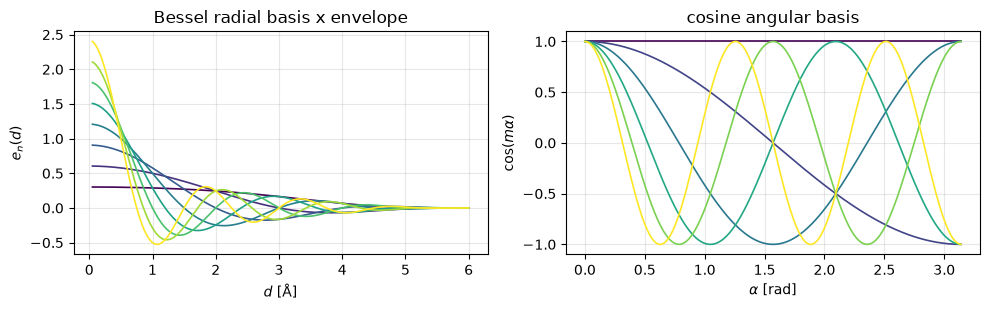

In [7]:
# Create the figure and axes for the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2))

# Create a grid of distances and compute the Bessel radial basis functions
d = torch.linspace(0.05, 6.0, 400)
eb = BesselRBF(6.0)(d)

# Plot the Bessel radial basis functions
colors = plt.get_cmap("viridis")(np.linspace(0, 1, eb.shape[1]))   # sequential: ordered n
for k in range(eb.shape[1]):
    ax1.plot(d, eb[:, k], color=colors[k], lw=1.2)
ax1.set_xlabel(r"$d$ [Å]"); ax1.set_ylabel(r"$e_n(d)$")
ax1.set_title("Bessel radial basis x envelope"); ax1.grid(True, alpha=0.3)

# Create a grid of angles and compute the cosine basis functions
alpha = torch.linspace(0, np.pi, 400)
cb = cos_basis(torch.cos(alpha), 6)

# Plot the cosine basis functions
colors = plt.get_cmap("viridis")(np.linspace(0, 1, cb.shape[1]))
for m in range(cb.shape[1]):
    ax2.plot(alpha, cb[:, m], color=colors[m], lw=1.2)
ax2.set_xlabel(r"$\alpha$ [rad]"); ax2.set_ylabel(r"$\cos(m\alpha)$")
ax2.set_title("cosine angular basis"); ax2.grid(True, alpha=0.3)
fig.tight_layout()

### Triplets

The directed edges are given by `edge_index` (receiver $i$, sender $j$: Lesson
05a convention). A **triplet** represents a pair of edges, $(k \to j,\ j \to
i)$, with $k \neq i$. As a result, the message, $m_{kj}$, feeds the update of
$m_{ji}$. We find all such pairs once per (static) training set with a dense
comparison: It's memory cost is $O(E^2)$ which is fine for our course's tiny
graphs. However, the production codes use more efficient sorted/CSR neighbor
lists. The angle at vertex $j$ is computed *in the forward pass* from positions
(it must stay in the autograd graph). The cosine of the angle is computed as

$$
\cos\alpha^{(kj,ji)} = \frac{(\vec x_k - \vec x_j) \cdot (\vec x_i - \vec x_j)}
{\lVert \vec x_k - \vec x_j \rVert\, \lVert \vec x_i - \vec x_j \rVert}.
$$

In [8]:
def find_triplets(edge_index):
    '''All edge pairs (a: k->j, b: j->i) with k != i. Returns (a_idx, b_idx) into edges.'''
    
    # Edge e: send[e] -> recv[e]
    recv, send = edge_index
    
    # a's receiver j == b's sender j
    match = recv.unsqueeze(1) == send.unsqueeze(0)
    
    # a's sender k != b's receiver i
    not_backtrack = send.unsqueeze(1) != recv.unsqueeze(0)
    
    # Return the indices of the triplet edges
    a_idx, b_idx = (match & not_backtrack).nonzero(as_tuple=True)
    return a_idx, b_idx

# Sanity check on one frame
_pos = make_lj_argon_dataset(n_frames=1)[0]["pos"]
_ei = radius_graph(_pos, 6.0)
_a, _b = find_triplets(_ei)
print(f"frame with {_ei.shape[1]} directed edges -> {len(_a)} triplets")

frame with 30 directed edges -> 96 triplets


### The model

Each interaction block in our DimeNet++-style model involves a Hadamard
multiplication in the interaction function, $f_\text{int}$, followed by a
residual update function, $f_\text{update}$:

$$
s_{ji} = \sum_{k \in \mathcal{N}_j \setminus \{i\}} f_\text{int}(\cdot),
$$

$$
f_\text{int}\big(m_{kj}, e^{(ji)}, a^{(kj,ji)}\big)
= \big(W_e\, e_\mathrm{RBF}^{(ji)}\big) \odot \big(W_a\, a_\mathrm{SBF}^{(kj,ji)}\big) \odot \mathrm{SiLU}\big(W_m\, m_{kj}\big),
$$

$$ m^{(l+1)}_{ji} = f_\text{update}(m^{(l)}_{ji}, s_{ji}) = m^{(l)}_{ji} +
\mathrm{SiLU}\big(W_2\, \mathrm{SiLU}(W_1 [\, m^{(l)}_{ji} \Vert s_{ji}\,])\big). $$

Then, the readout yields the updated the atomic features via messages $h_i =
\sum_j m_{ji},$ and atom-wise dense layers use them to yield a per-atom energy,
summed to $\hat E$.

Let us implement this in code:

In [9]:
class DirectionalInteraction(nn.Module):
    """A directional interaction block in the DimeNet++ architecture."""
    
    def __init__(self, F: int, n_rbf: int, n_ang: int):
        super().__init__()
        # Gate by e_RBF(d_ji)
        self.W_e = nn.Linear(n_rbf, F, bias=False)
            
        # Filter from joint (d_kj, angle) basis
        self.W_a = nn.Linear(n_rbf * n_ang, F, bias=False)
        
        # Transform incoming message m_kj
        self.W_m = nn.Linear(F, F)
        
        # Residual update
        self.W_1 = nn.Linear(2 * F, F)
        self.W_2 = nn.Linear(F, F)

    # f_int: Hadamard product over each triplet (k->j, j->i)
    def forward(self, m, e, a, trip_a, trip_b):
        # Compute the message for each triplet (k->j, j->i)    
        t = self.W_e(e)[trip_b] * self.W_a(a) * silu(self.W_m(m[trip_a]))
        
        # Sum over k in N(j)\{i}
        s = torch.zeros_like(m).index_add_(0, trip_b, t)
        
        # f_update
        return m + silu(self.W_2(silu(self.W_1(torch.cat([m, s], dim=-1)))))

In [10]:
class SimpleDimeNet(nn.Module):
    """A simple DimeNet++ model for energy prediction."""
    
    def __init__(self, n_features=64, n_blocks=2, r_cut=6.0, n_rbf=8, n_ang=6, n_species=1):
        super().__init__()
        # Create the Bessel radial basis functions
        self.rbf = BesselRBF(r_cut, n_rbf)
        
        # Embedding for atomic species
        self.embedding = nn.Embedding(n_species, n_features)
        
        # Edge embedding: concatenates h_i, h_j, and e_RBF(d_ji) to produce m_ji
        self.edge_embed = nn.Linear(2 * n_features + n_rbf, n_features)
        
        # Create a stack of directional interaction blocks
        self.blocks = nn.ModuleList(
            [DirectionalInteraction(n_features, n_rbf, n_ang) for _ in range(n_blocks)])
        
        # Readout: two dense layers to produce a per-atom energy
        self.readout1 = nn.Linear(n_features, n_features // 2)
        self.readout2 = nn.Linear(n_features // 2, 1)
        
        # Number of angular basis functions
        self.n_ang = n_ang

    # Forward pass: compute the energy of a point cloud
    def forward(self, pos, species, edge_index, trip_a, trip_b, batch, n_graphs):
        # Edge index: recv = j, send = i for each edge j->i
        recv, send = edge_index
        
        # Compute d_ji: distance from atom j to atom i
        d = (pos[send] - pos[recv]).norm(dim=-1)
        
        # Compute the radial basis functions
        e = self.rbf(d)
        
        # Compute the initial node features h_i from the atomic species
        h = self.embedding(species)
        
        # Compute the edge features m_ji
        m = silu(self.edge_embed(torch.cat([h[send], h[recv], e], dim=-1)))
        
        # x_k - x_j
        u = pos[send[trip_a]] - pos[recv[trip_a]]
        
        # x_i - x_j
        v = pos[recv[trip_b]] - pos[send[trip_b]]
        
        # Compute the cosine of the angle alpha between u and v
        cos_alpha = (u * v).sum(-1) / (u.norm(dim=-1) * v.norm(dim=-1))
        
        # e_RBF(d_kj) x cos(m alpha)
        a = (self.rbf(u.norm(dim=-1)).unsqueeze(-1)
             * cos_basis(cos_alpha, self.n_ang).unsqueeze(-2)).flatten(-2)
        
        # Apply the directional interaction blocks
        for block in self.blocks:
            m = block(m, e, a, trip_a, trip_b)
        
        # h_i = sum_j m_ji
        h_i = torch.zeros(len(pos), m.shape[-1], dtype=pos.dtype,
                          device=pos.device).index_add_(0, recv, m)
        
        # Readout: compute the per-atom energies E_i and sum over all atoms in each graph
        E_i = self.readout2(silu(self.readout1(h_i))).squeeze(-1)
        E = torch.zeros(n_graphs, dtype=pos.dtype, device=pos.device)
        
        # E = sum_i E_i
        return E.index_add_(0, batch, E_i)

Let's initilize the model and print the number of parameters.

In [11]:
model = SimpleDimeNet().to(device)
print("SimpleDimeNet parameters:", sum(p.numel() for p in model.parameters()))

SimpleDimeNet parameters: 51265


### Does it resolve the counterexample?

Before we proceed with training our DimeNet++ model, let's perform another
experiment with $\mathcal{A}^+/\mathcal{A}^-$ pair, again with **random
untrained weights**: if the architecture carries angular information, as it does
in the case of DimeNet++, the two structures should already map to different
outputs.

In [19]:
# Fully connected graph at r_cut = 10 Å
dime64 = SimpleDimeNet(r_cut=10.0).double()

# Compute the energies of the two structures using the float64 DimeNet model
def dime_energy(pos):
    ei = radius_graph(pos, 10.0)
    ta, tb = find_triplets(ei)
    z = torch.zeros(len(pos), dtype=torch.long); b = torch.zeros(len(pos), dtype=torch.long)
    return dime64(pos, z, ei, ta, tb, b, 1).item()

E_p, E_m = dime_energy(A_plus), dime_energy(A_minus)
print(f"SimpleDimeNet(A+) = {E_p:.8f}\nSimpleDimeNet(A-) = {E_m:.8f}")
print(f"difference = {abs(E_p - E_m):.3e}   <- angles break the degeneracy")

SimpleDimeNet(A+) = -14.53793127
SimpleDimeNet(A-) = -14.53755786
difference = 3.734e-04   <- angles break the degeneracy


## Training on LJ argon and a comparison with SchNet

Same data, split, standardization, loss ($\rho = 1$, SchNet Eq. (5) — see 07a), optimizer and schedule as Lesson 07a; forces from autograd exactly as before. The only new ingredient in the pipeline is the precomputed triplet list per batch.

**Expectation management.** The Lennard-Jones energy is a *pure pair potential*, $E = \sum_{i<j} 4\varepsilon\big[(\sigma/d_{ij})^{12} - (\sigma/d_{ij})^{6}\big]$ — a function of distances only, perfectly representable by a distance-based model. Angular features add **no missing physics** on this dataset, so DimeNet-style gains should be small or absent here; we train it anyway to validate the implementation and the pipeline. Angular information matters when the target actually depends on it: covalent/directional bonding (the water bend, sp³ angles, torsions), many-body metals and semiconductors (e.g. silicon phases), and — as in Section 1 — whenever distance-degenerate configurations occur. On benchmarks of real molecules (QM9, MD17) DimeNet beats SchNet by 31–76 % on average (Gasteiger et al., Sec. 7).

In [13]:
frames = make_lj_argon_dataset(n_frames=200, n_atoms=8, seed=0)
train_frames, val_frames = train_val_split(frames, val_fraction=0.25, seed=0)
n_atoms = frames[0]["pos"].shape[0]
E_train = np.array([f["energy"] for f in train_frames])
eps_bar = E_train.mean() / n_atoms                       # per-atom mean shift (see 07a)
R_CUT = 6.0

def make_batch(frame_list, device):
    '''One disconnected graph: pos, species, edges, triplets, batch, E~, F.'''
    pos, species, edges, batch, E, F = [], [], [], [], [], []
    offset = 0
    for g, f in enumerate(frame_list):
        p = f["pos"].float()
        pos.append(p); species.append(torch.zeros(len(p), dtype=torch.long))
        edges.append(radius_graph(p, R_CUT) + offset)
        batch.append(torch.full((len(p),), g, dtype=torch.long))
        E.append(f["energy"] - len(p) * eps_bar); F.append(f["forces"].float())
        offset += len(p)
    edge_index = torch.cat(edges, dim=1)
    trip_a, trip_b = find_triplets(edge_index)           # precomputed once (static geometry)
    return (torch.cat(pos).to(device), torch.cat(species).to(device),
            edge_index.to(device), trip_a.to(device), trip_b.to(device),
            torch.cat(batch).to(device),
            torch.tensor(E, dtype=torch.float32, device=device), torch.cat(F).to(device))

train_batch = make_batch(train_frames, device)
val_batch   = make_batch(val_frames, device)
print(f"{len(train_frames)} train / {len(val_frames)} val frames | train graph: "
      f"{train_batch[0].shape[0]} atoms, {train_batch[2].shape[1]} edges, {len(train_batch[3])} triplets")

150 train / 50 val frames | train graph: 1200 atoms, 4044 edges, 11720 triplets


In [14]:
def energy_and_forces(model, pos, species, edge_index, trip_a, trip_b, batch, n_graphs,
                      create_graph=False):
    pos = pos.requires_grad_(True)
    E = model(pos, species, edge_index, trip_a, trip_b, batch, n_graphs)
    (dE_dpos,) = torch.autograd.grad(E.sum(), pos, create_graph=create_graph)
    return E, -dE_dpos                                   # F_i = -dE/dr_i  (07a, Sec. 5)

def eval_mae(model, batch):
    *inputs, E_ref, F_ref = batch
    E, F = energy_and_forces(model, *inputs, len(E_ref))
    return ((E - E_ref).abs().mean().item() / n_atoms * 1e3,
            (F - F_ref).abs().mean().item() * 1e3)       # meV/atom, meV/Å

def loss_fn(E, F, E_ref, F_ref, rho=1.0):                # SchNet Eq. (5), as in 07a
    return rho * ((E_ref - E) ** 2).mean() + ((F_ref - F) ** 2).sum(dim=-1).mean() * 3.0

In [15]:
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=600)
history = {"train E MAE [meV/atom]": [], "val E MAE [meV/atom]": [],
           "train F MAE [meV/Å]": [], "val F MAE [meV/Å]": []}
*train_inputs, E_ref, F_ref = train_batch

t0 = time.time()
for epoch in range(600):
    model.train(); optimizer.zero_grad()
    E, F = energy_and_forces(model, *train_inputs, len(E_ref), create_graph=True)
    loss = loss_fn(E, F, E_ref, F_ref, rho=1.0)
    loss.backward(); optimizer.step(); scheduler.step()
    tr = eval_mae(model, train_batch); va = eval_mae(model, val_batch)
    for key, v in zip(history, (tr[0], va[0], tr[1], va[1])):
        history[key].append(v)
    if epoch % 100 == 0 or epoch == 599:
        print(f"epoch {epoch:4d}  loss {loss.item():.3e}   "
              f"val E MAE {va[0]:7.3f} meV/atom   val F MAE {va[1]:7.3f} meV/Å")
print(f"training time: {time.time() - t0:.1f} s on {device}")

epoch    0  loss 8.646e+00   val E MAE 606.744 meV/atom   val F MAE  16.277 meV/Å
epoch  100  loss 2.420e-03   val E MAE   1.066 meV/atom   val F MAE   7.459 meV/Å
epoch  200  loss 6.503e-04   val E MAE   0.885 meV/atom   val F MAE   3.903 meV/Å
epoch  300  loss 2.699e-04   val E MAE   0.933 meV/atom   val F MAE   3.279 meV/Å
epoch  400  loss 2.100e-04   val E MAE   0.871 meV/atom   val F MAE   2.886 meV/Å
epoch  500  loss 1.899e-04   val E MAE   0.833 meV/atom   val F MAE   2.770 meV/Å
epoch  599  loss 1.871e-04   val E MAE   0.827 meV/atom   val F MAE   2.755 meV/Å
training time: 22.2 s on cuda


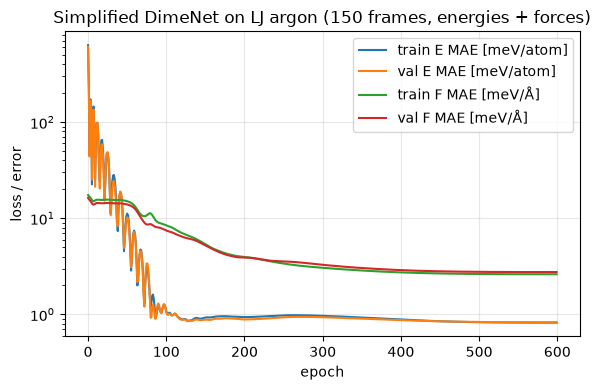

In [16]:
ax = plot_training_curves(history)
ax.set_title("Simplified DimeNet on LJ argon (150 frames, energies + forces)")
ax.figure.tight_layout()

                     model |  val E MAE [meV/atom] |  val F MAE [meV/Å]
       SchNet (Lesson 07a) |                 0.118 |              0.622
SimpleDimeNet (Lesson 07b) |                 0.827 |              2.755


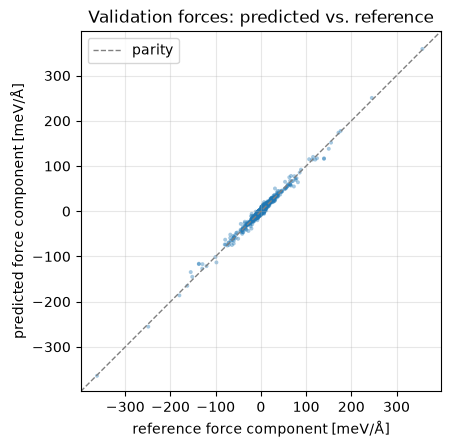

In [17]:
model.eval()
_, F_val = energy_and_forces(model, *val_batch[:6], len(val_batch[6]))
F_pred = F_val.detach().cpu().numpy().ravel() * 1e3
F_true = val_batch[7].cpu().numpy().ravel() * 1e3

fig, ax = plt.subplots(figsize=(4.6, 4.6))
lim = np.abs(F_true).max() * 1.1
ax.plot([-lim, lim], [-lim, lim], "--", color="gray", lw=1, label="parity")
ax.scatter(F_true, F_pred, s=8, alpha=0.4, color="C0", edgecolors="none")
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("reference force component [meV/Å]")
ax.set_ylabel("predicted force component [meV/Å]")
ax.set_title("Validation forces: predicted vs. reference")
ax.legend(); ax.grid(True, alpha=0.3); fig.tight_layout()

e_mae, f_mae = eval_mae(model, val_batch)
schnet_07a = {"E": 0.118, "F": 0.622}      # Lesson 07a final numbers (same data/split/seed)
print(f"{'model':>26} | {'val E MAE [meV/atom]':>21} | {'val F MAE [meV/Å]':>18}")
print(f"{'SchNet (Lesson 07a)':>26} | {schnet_07a['E']:>21.3f} | {schnet_07a['F']:>18.3f}")
print(f"{'SimpleDimeNet (Lesson 07b)':>26} | {e_mae:>21.3f} | {f_mae:>18.3f}")

Both models reach sub-meV accuracy, and the angular model brings **no decisive advantage here** — exactly as argued above: LJ argon is a pair potential, so distances already contain everything. Keep this experiment in mind as a control: architectural sophistication only pays when the *data* contains the corresponding physics. On angle-dependent systems (molecules, covalent solids, the degenerate pairs of Section 1) the picture reverses dramatically.

## Numerical verification of invariance

Distances and angles are both invariant under $E(3)$ (including parity: $\cos\alpha$ is a ratio of dot products, both parity-even), so the energy must be a `0e` scalar and the forces `1o` vectors — same tests as 07a, with the graph *and triplets* rebuilt after each transform. (As in 07a, the harness's force check is limited to $\sim 10^{-7}$ by e3nn's `D_from_matrix`; the direct check against $R$ itself confirms exactness in float64.)

In [18]:
model64 = copy.deepcopy(model).double().cpu().eval()
pos_test = val_frames[0]["pos"].clone()
z_test = torch.zeros(n_atoms, dtype=torch.long); b_test = torch.zeros(n_atoms, dtype=torch.long)

def graph_of(pos):
    ei = radius_graph(pos.detach() if pos.requires_grad else pos, R_CUT)
    return (ei, *find_triplets(ei))

def energy_fn(pos):
    ei, ta, tb = graph_of(pos)
    return model64(pos, z_test, ei, ta, tb, b_test, 1).reshape(1)

def force_fn(pos):
    ei, ta, tb = graph_of(pos)
    _, F = energy_and_forces(model64, pos, z_test, ei, ta, tb, b_test, 1)
    return F

print("energy  E(RX + t) = E(X):")
assert_model_equivariant(energy_fn, pos_test, "0e", tol=1e-12)
print("forces  F(RX + t) = R F(X)  (harness):")
assert_model_equivariant(force_fn, pos_test, "1o", tol=1e-6)

from e3nn import o3
err, F_ref = 0.0, force_fn(pos_test)
for _ in range(5):
    R = o3.rand_matrix(dtype=torch.float64)
    if torch.rand(()) < 0.5: R = -R                      # improper rotations: parity too
    t = torch.randn(3, dtype=torch.float64)
    err = max(err, (force_fn(pos_test @ R.T + t) - F_ref @ R.T).abs().max().item())
assert err < 1e-12, err
print(f"forces exactly covariant: max |F(RX+t) - R F(X)| = {err:.3e}  (float64)")

energy  E(RX + t) = E(X):
equivariant!  (max error 6.245e-17 over random O(3) + translations elements)
forces  F(RX + t) = R F(X)  (harness):
equivariant!  (max error 1.014e-08 over random O(3) + translations elements)
forces exactly covariant: max |F(RX+t) - R F(X)| = 5.135e-16  (float64)


## What do triplets cost? $O(Nk^2)$ vs. $O(Nk)$

Let $k$ be the average number of neighbors within the cutoff. Per structure:

- **Pairwise message passing (07a):** one message per directed edge → $O(Nk)$ messages.
- **Directional message passing (07b):** one interaction per edge *pair* sharing a vertex, $\sum_j \deg(j)\big(\deg(j) - 1\big) \approx O(Nk^2)$ triplets.

Our training batch above makes this concrete: with $N = 1200$ atoms we had $\approx 4000$ edges but $\approx 10^4$ triplets — and our LJ gas is *dilute* ($k \approx 3.4$). In a liquid or solid with $k \approx 30{-}60$, the $k^2$ factor is a 1–2 order-of-magnitude overhead, and extending the same logic to torsions/dihedrals (GemNet-style quadruplets) costs $O(Nk^3)$. DimeNet++'s Hadamard trick cuts the constant ~8×, but the *scaling* stands.

**The way out (Part IV):** instead of enumerating triplets of invariant scalars, let each message itself carry directional content — spherical-harmonic features of order $l > 0$ that *rotate* with the structure (Lessons 02b–06a). A tensor product of two $l = 1$ features already encodes angular correlations, so equivariant networks capture 3-body (and higher) geometry with only $O(Nk)$ messages. That is precisely the design of NequIP — Lesson 08a.

## Summary

- **dGNNs are incomplete:** the Pozdnyakov–Ceriotti $\mathcal{A}^\pm$ pairs (Eqs. (2)–(3) of their paper) share every per-node distance multiset at any cutoff, yet are genuinely different — we built them, verified the distance/angle multisets, and showed a random dGNN outputs identical energies while our angular model separates them.
- **Directional message passing** (DimeNet, Eq. (4)) embeds *directed edges* $m_{ji}$, aggregates over **triplets** with a joint basis in $(d_{kj}, \alpha^{(kj,ji)})$, and stays invariant because distances and angles are invariant scalars.
- **Physically motivated bases:** radial Bessel functions (Eq. (7)) with a smooth envelope (Eq. (8)); DimeNet++ replaces the bilinear triplet layer with a Hadamard product (8× faster).
- On **LJ argon the angular machinery buys little** — the target is a pair potential; angular features matter for covalent/directional systems and degenerate geometries.
- Triplets cost $O(Nk^2)$ vs. $O(Nk)$ for pairwise messages — the price of injecting geometry through invariant scalars, and the motivation for **equivariant** networks (Part IV).

**Next:** Lesson 08a — NequIP: equivariant features as the principled, $O(Nk)$ carrier of directional information.

## Exercises

**1. Near-degenerate structures.** Add Gaussian noise of scale $\epsilon \in \{10^{-3}, 10^{-2}, 10^{-1}\}$ Å to $\mathcal{A}^+$ and $\mathcal{A}^-$ and evaluate `MiniDGNN` on both. How does $|E(\mathcal{A}^+) - E(\mathcal{A}^-)|$ grow with $\epsilon$? Relate to Fig. 5 of Pozdnyakov & Ceriotti: why does the degeneracy hurt even structures that are *not exactly* degenerate?

<details><summary>Solution</summary>

The energy difference grows roughly linearly with $\epsilon$ from zero: at $\epsilon = 0$ the outputs coincide exactly, and smoothness of the network makes nearby structures map to nearby outputs. This is precisely the paper's Fig. 5 argument: a *smooth* incomplete model must assign nearly equal predictions to the whole neighborhood of a degenerate pair, so its error floor extends to a finite volume of configuration space, not just a measure-zero manifold. </details>

**2. Ablate the angles.** Set `n_ang=1` in `SimpleDimeNet` (the angular basis reduces to the constant $T_0 = 1$, so triplet aggregation still happens but carries no angular resolution) and re-run the counterexample check and the training. What changes?

<details><summary>Solution</summary>

With `n_ang=1` the interaction uses only $e_{\mathrm{RBF}}(d_{kj})$ — distances again. The model becomes a (fancier) dGNN: the counterexample energies coincide once more, while the LJ validation errors stay essentially unchanged (LJ needs no angles anyway). This isolates *where* the extra expressive power comes from: the $m \geq 1$ angular basis functions. </details>

**3. Measure the scaling.** Generate LJ frames with `n_atoms` ∈ {8, 16, 32, 64} (increase `box` proportionally to keep density constant) and count edges and triplets at $r_\mathrm{cut} = 6$ Å. Plot both vs. $N$ on a log–log scale. Do the slopes match $O(Nk)$ and $O(Nk^2)$ with constant $k$?

<details><summary>Solution</summary>

At constant density $k$ is constant, so both counts grow linearly in $N$ — parallel lines on the log–log plot, with the triplet line offset upward by roughly a factor $k - 1$. The $k^2$ pain appears when the *density* (or cutoff) grows: doubling $k$ doubles the edge count but quadruples the triplet count. Repeat with `box` fixed while increasing `n_atoms` to see the slopes separate. </details>

## References

- Gasteiger, Groß & Günnemann, *Directional Message Passing for Molecular Graphs* arXiv.2003.03123 (2022), Eqs. (1)–(9) — [Gasteiger et al. (2022)](https://arxiv.org/pdf/2003.03123).
- Gasteiger et al., *Fast and Uncertainty-Aware Directional Message Passing for Non-Equilibrium Molecules* (2020), Sec. 3 (DimeNet++) — [Gasteiger arXiv 2011.14115 2020](https://arxiv.org/pdf/2011.14115).
- Pozdnyakov & Ceriotti, *Incompleteness of graph neural networks for point clouds in three dimensions* (Mach. Learn.: Sci. Technol. 2022), Sec. III, Eqs. (2)–(3), Figs. 1 & 4 — [Pozdnyakov arXiv 2201.07136 2022](https://arxiv.org/pdf/2201.07136).